In [1]:
import pandas as pd

df = pd.read_excel('Dataset for Data Analytics4.xlsx')

print(df.head())
print(df.info())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

df.dropna(subset=['OrderID', 'TotalPrice'], inplace=True)

In [7]:
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print(product_revenue)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


In [13]:
df['MonthYear'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('MonthYear')['TotalPrice'].sum()

print(monthly_sales)

MonthYear
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64


In [15]:
referral_performance = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

payment_counts = df['PaymentMethod'].value_counts()

print(referral_performance)
print(payment_counts)

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


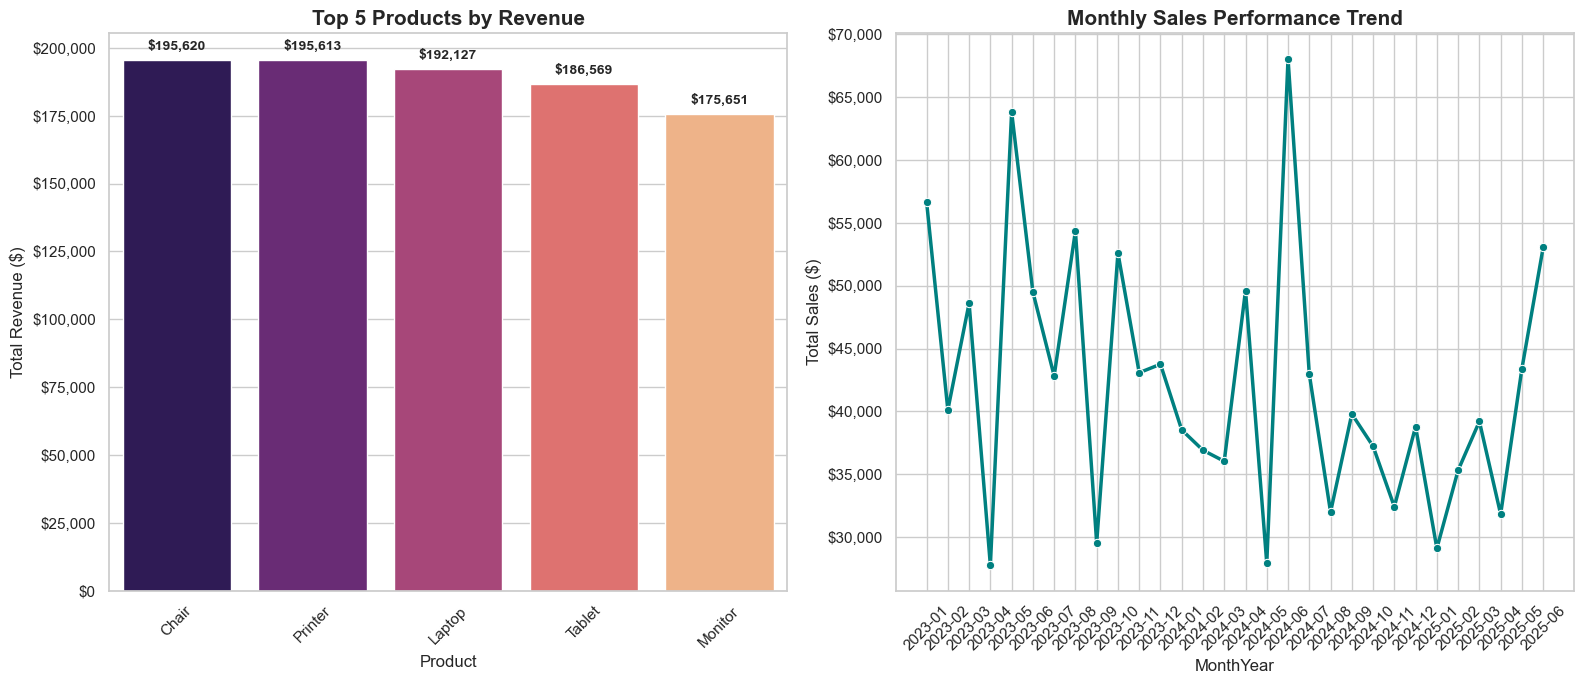

Total Records Processed: 1200

Top 5 Products Revenue:
   Product  TotalPrice
0    Chair   195620.11
1  Printer   195612.61
2   Laptop   192126.56
3   Tablet   186568.95
4  Monitor   175651.41


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

file_path = 'Dataset for Data Analytics4.xlsx'
df = pd.read_excel(file_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df['MonthYear'] = df['Date'].dt.to_period('M').astype(str)

product_rev = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
monthly_trend = df.groupby('MonthYear')['TotalPrice'].sum().reset_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 7))

ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=product_rev.head(5), x='Product', y='TotalPrice', hue='Product', palette='magma')
if ax1.get_legend(): ax1.get_legend().remove()
plt.title('Top 5 Products by Revenue', fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue ($)')

for p in ax1.patches:
    ax1.annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10, fontweight='bold')

ax2 = plt.subplot(1, 2, 2)
sns.lineplot(data=monthly_trend, x='MonthYear', y='TotalPrice', marker='o', color='teal', linewidth=2.5)
plt.title('Monthly Sales Performance Trend', fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Total Sales ($)')

formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax1.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

print(f"Total Records Processed: {len(df)}")
print("\nTop 5 Products Revenue:")
print(product_rev.head(5))